https://www.kaggle.com/datasets/mirichoi0218/insurance

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [2]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

extract_path = "/content/insurance_data"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted files:")
print(os.listdir(extract_path))

Extracted files:
['insurance.csv']


In [3]:
import glob

csv_files = glob.glob(extract_path + "/*.csv")

print(csv_files)

['/content/insurance_data/insurance.csv']


In [4]:
import pandas as pd

df = pd.read_csv(csv_files[0])

print("Shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
display(df.describe(include="all"))

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


In [7]:
df = df.drop_duplicates().reset_index(drop=True)

print("New shape:", df.shape)

New shape: (1337, 7)


In [8]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


sex:
sex
male      675
female    662
Name: count, dtype: int64

smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


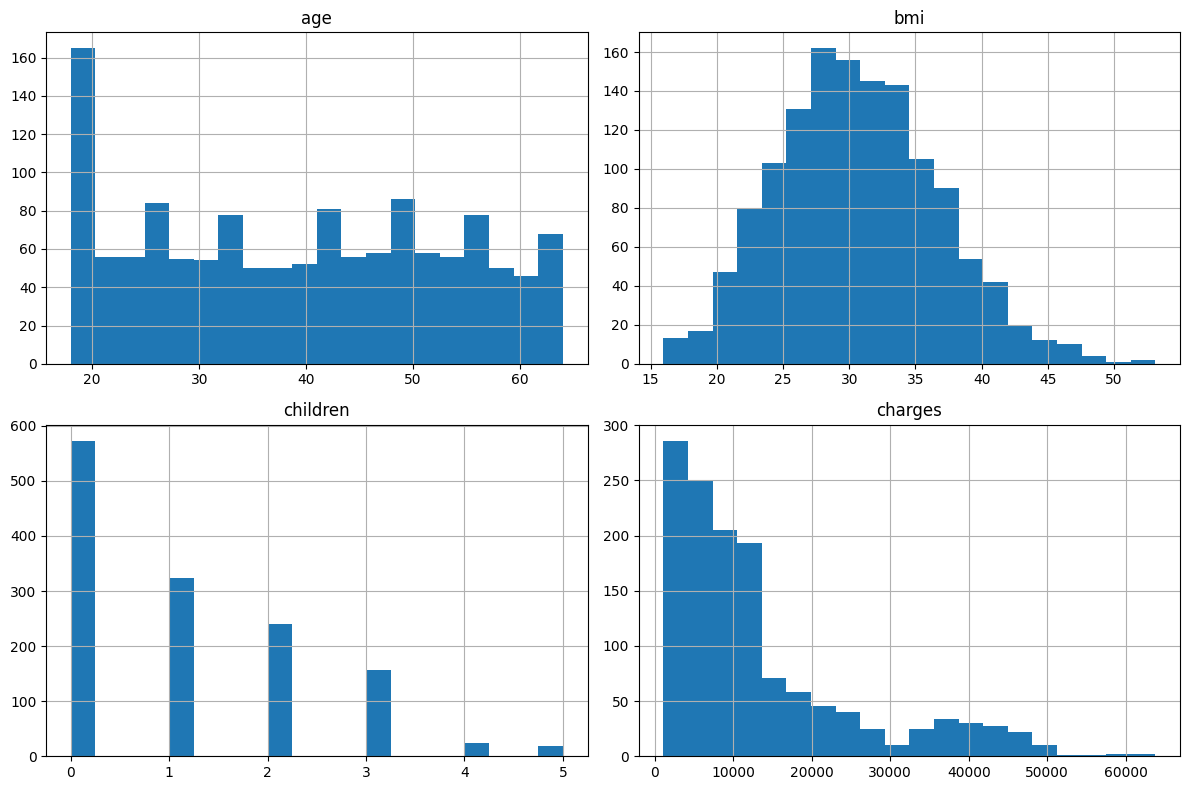

In [9]:
import matplotlib.pyplot as plt

df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

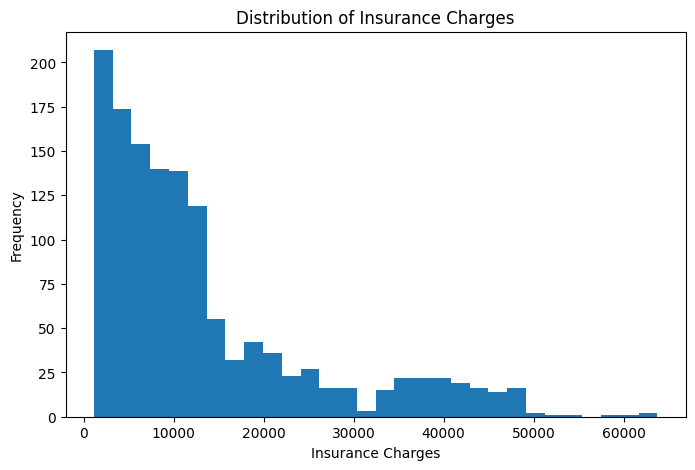

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["charges"], bins=30)
plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Insurance Charges")
plt.show()

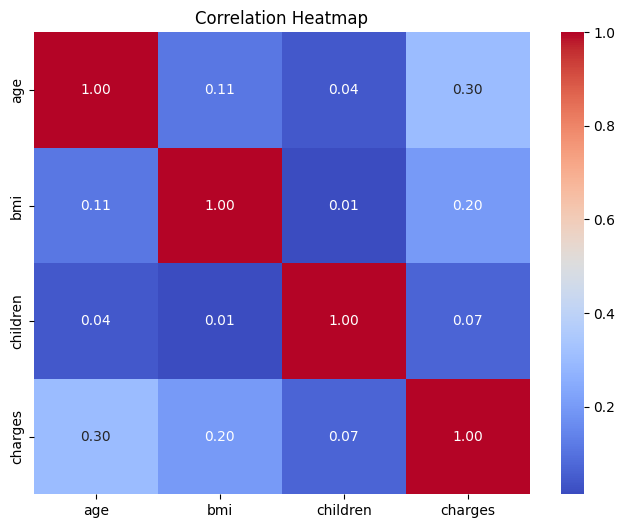

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

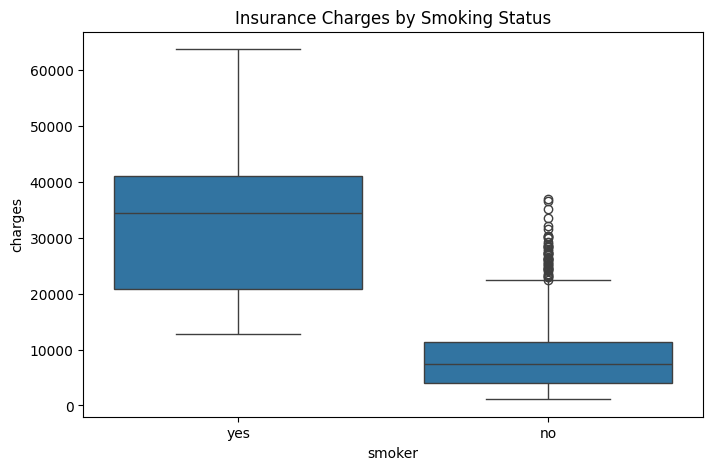

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Insurance Charges by Smoking Status")
plt.show()

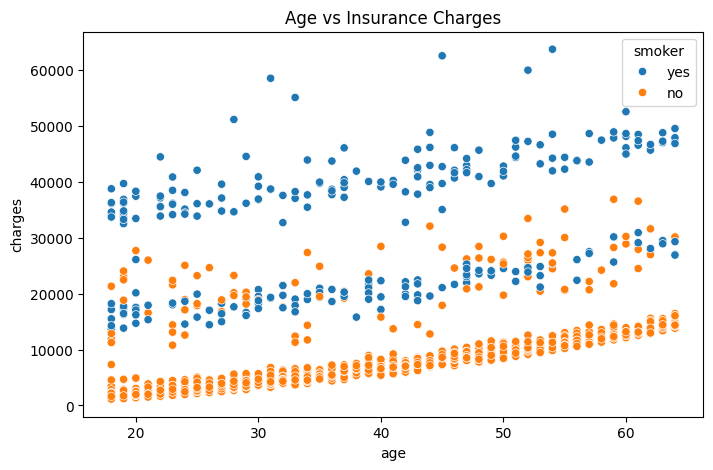

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker")
plt.title("Age vs Insurance Charges")
plt.show()

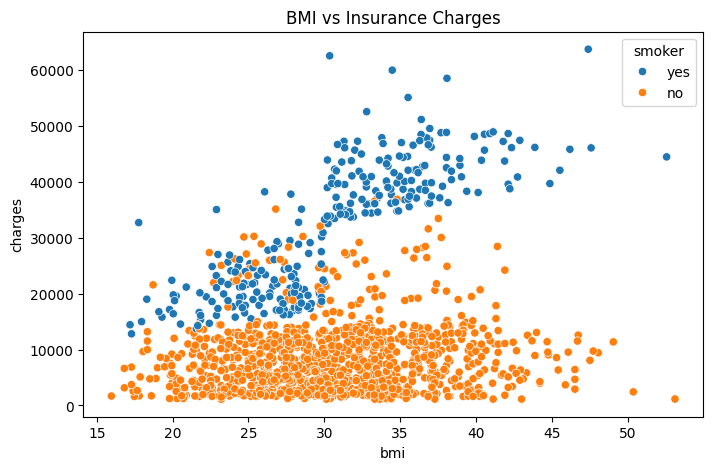

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs Insurance Charges")
plt.show()

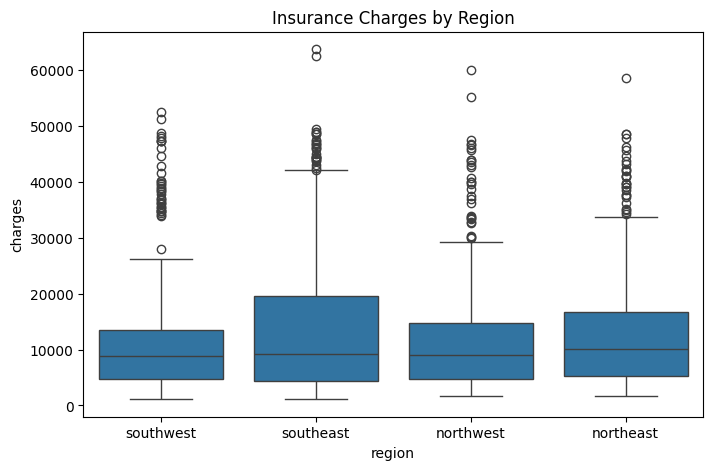

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="region", y="charges")
plt.title("Insurance Charges by Region")
plt.show()

In [16]:
print("Average charges by smoker:")
display(df.groupby("smoker")["charges"].mean().round(2))

print("\nAverage charges by region:")
display(df.groupby("region")["charges"].mean().round(2))

print("\nAverage charges by sex:")
display(df.groupby("sex")["charges"].mean().round(2))

Average charges by smoker:


,charges
smoker,
no,8440.66
yes,32050.23



Average charges by region:


,charges
region,
northeast,13406.38
northwest,12450.84
southeast,14735.41
southwest,12346.94



Average charges by sex:


,charges
sex,
female,12569.58
male,13975.00


In [17]:
from sklearn.model_selection import train_test_split

X = df.drop("charges", axis=1)
y = df["charges"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1069, 8)
Testing shape: (268, 8)


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)
display(results_df.sort_values("R2 Score", ascending=False))

,Model,MAE,RMSE,R2 Score
2,Gradient Boosting,2517.467831,4268.283018,0.900856
1,Random Forest,2611.273683,4664.686756,0.881586
0,Linear Regression,4177.045561,5956.342894,0.806929


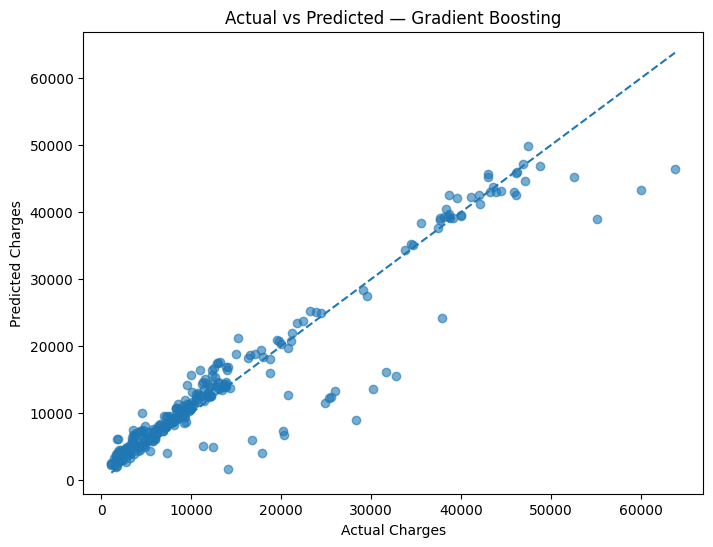

Best model: Gradient Boosting


In [20]:
best_model_name = results_df.loc[
    results_df["R2 Score"].idxmax(), "Model"
]

best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title(f"Actual vs Predicted — {best_model_name}")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

print("Best model:", best_model_name)

,Feature,Importance
4,smoker_yes,0.672198
1,bmi,0.187525
0,age,0.123421
2,children,0.014558
7,region_southwest,0.000877
3,sex_male,0.000718
5,region_northwest,0.000389
6,region_southeast,0.000313


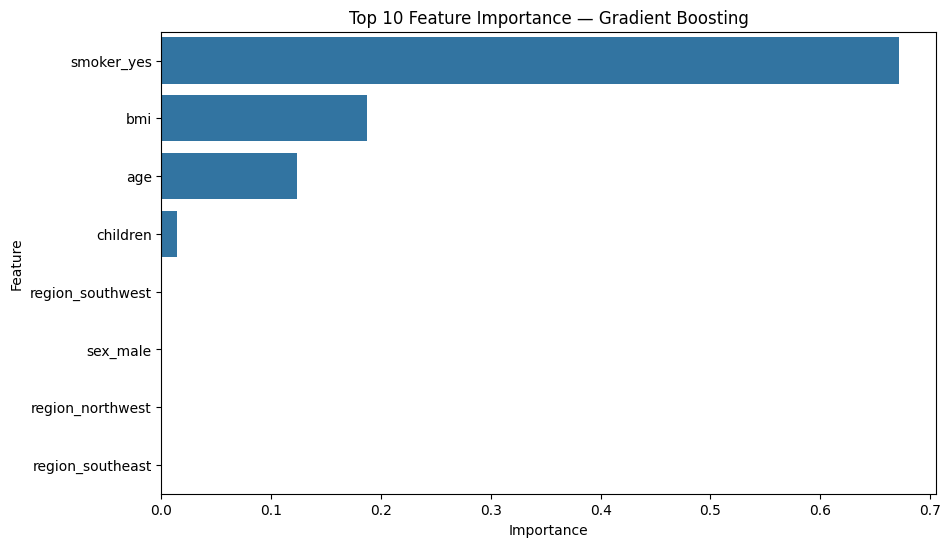

In [21]:
if best_model_name in ["Random Forest", "Gradient Boosting"]:
    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=importance.head(10),
        x="Importance",
        y="Feature"
    )
    plt.title(f"Top 10 Feature Importance — {best_model_name}")
    plt.show()

In [22]:
import joblib

model_data = {
    "model": best_model,
    "features": X.columns.tolist()
}

joblib.dump(model_data, "insurance_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [23]:
loaded_data = joblib.load("insurance_model.pkl")

print("Model:", type(loaded_data["model"]).__name__)
print("Number of features:", len(loaded_data["features"]))

Model: GradientBoostingRegressor
Number of features: 8


In [24]:
from google.colab import files

files.download("insurance_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Streamlit

In [25]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# -----------------------------
# Page Configuration
# -----------------------------
st.set_page_config(
    page_title="Insurance Cost Predictor",
    page_icon="🏥",
    layout="wide"
)

# -----------------------------
# Load Model
# -----------------------------
model_data = joblib.load("insurance_model.pkl")
model = model_data["model"]
features = model_data["features"]

# -----------------------------
# Title
# -----------------------------
st.title("🏥 Health Insurance Cost Predictor")
st.markdown(
    "Predict estimated medical insurance charges using a machine learning model."
)

st.divider()

# -----------------------------
# Sidebar
# -----------------------------
st.sidebar.header("Customer Information")

age = st.sidebar.slider(
    "Age", 18, 100, 30
)

sex = st.sidebar.selectbox(
    "Sex", ["male", "female"]
)

bmi = st.sidebar.number_input(
    "BMI",
    min_value=10.0,
    max_value=60.0,
    value=25.0,
    step=0.1
)

children = st.sidebar.slider(
    "Number of Children",
    0, 5, 0
)

smoker = st.sidebar.selectbox(
    "Smoker", ["yes", "no"]
)

region = st.sidebar.selectbox(
    "Region",
    ["northeast", "northwest", "southeast", "southwest"]
)

# -----------------------------
# Create Input DataFrame
# -----------------------------
input_data = pd.DataFrame({
    "age": [age],
    "sex": [sex],
    "bmi": [bmi],
    "children": [children],
    "smoker": [smoker],
    "region": [region]
})

input_encoded = pd.get_dummies(input_data, drop_first=True)

# Match training columns exactly
input_encoded = input_encoded.reindex(
    columns=features,
    fill_value=0
)

# -----------------------------
# Prediction
# -----------------------------
st.subheader("🔮 Insurance Cost Prediction")

if st.button("Predict Insurance Cost", type="primary"):

    prediction = model.predict(input_encoded)[0]

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(
            "Estimated Insurance Cost",
            f"${prediction:,.2f}"
        )

    with col2:
        st.metric(
            "BMI",
            f"{bmi:.1f}"
        )

    with col3:
        st.metric(
            "Age",
            age
        )

    st.success(
        f"Estimated annual insurance charge: **${prediction:,.2f}**"
    )

# -----------------------------
# Customer Information
# -----------------------------
st.divider()

st.subheader("📋 Customer Information")

display_data = input_data.T.reset_index()
display_data.columns = ["Feature", "Value"]

st.dataframe(
    display_data,
    use_container_width=True,
    hide_index=True
)

st.caption(
    "This application provides an ML-based estimate and should not be "
    "considered a medical or financial decision-making tool."
)

Writing app.py


In [27]:
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
joblib

Writing requirements.txt


In [28]:
import os

print(os.listdir("/content"))

['.config', 'insurance_model.pkl', 'insurance_data', 'app.py', 'archive (3).zip', 'requirements.txt', 'sample_data']


In [29]:
!pip -q install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 90.4 MB/s eta 0:00:00


In [30]:
!streamlit run app.py &>/content/streamlit.log &

In [31]:
!streamlit run app.py &>/content/streamlit.log &

In [32]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /content/cloudflared
!chmod +x /content/cloudflared

In [33]:
!./cloudflared tunnel --url http://localhost:8501

2026-09-25T20:47:19Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-25T20:47:19Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-25T20:47:24Z INF +--------------------------------------------------------------------------------------------+
2026-09-25T20:47:24Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-25T20:47:24Z INF |  https://design-apparent-struck-set.trycloudflare.com 